# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rish7186/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

I examined the distributions of the numerical features to understand their shape, spread, and potential outliers. Histograms and boxplots were used to identify skewness and heavy-tailed distributions. Heavy-tailed features may require transformations such as log1p() before correlation analysis or model training.

Numerical Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


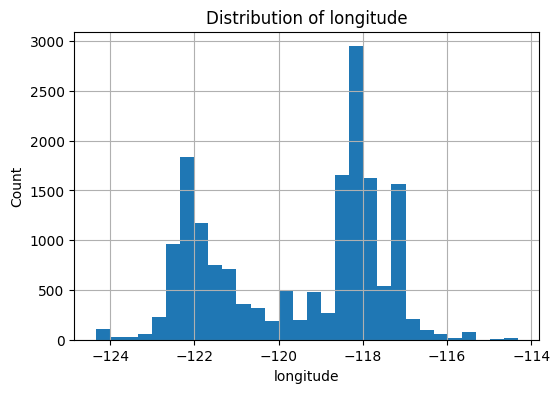

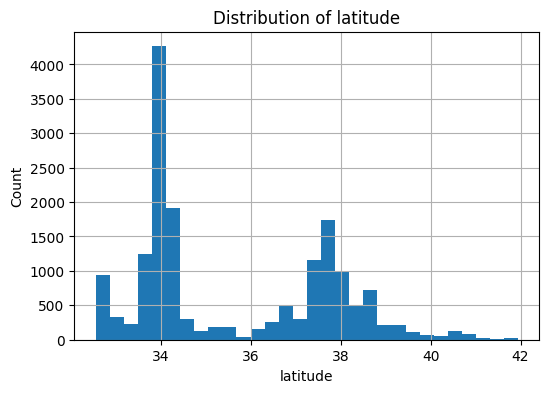

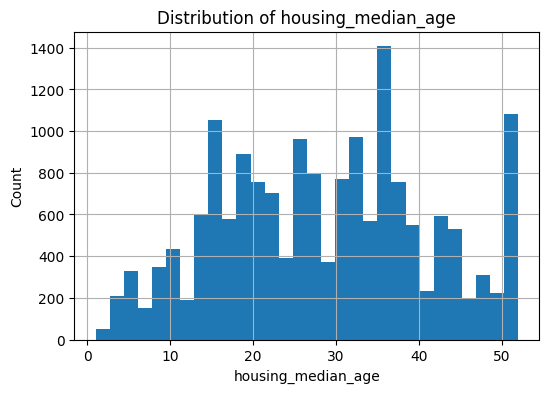

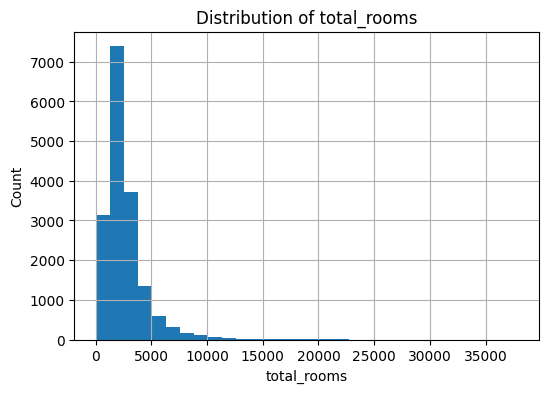

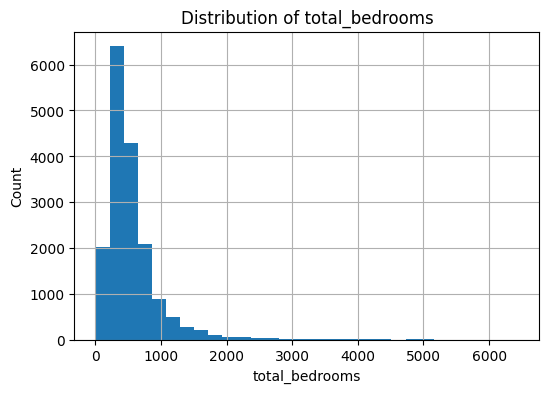

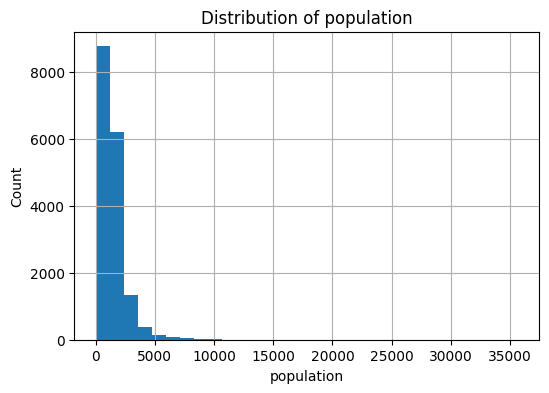

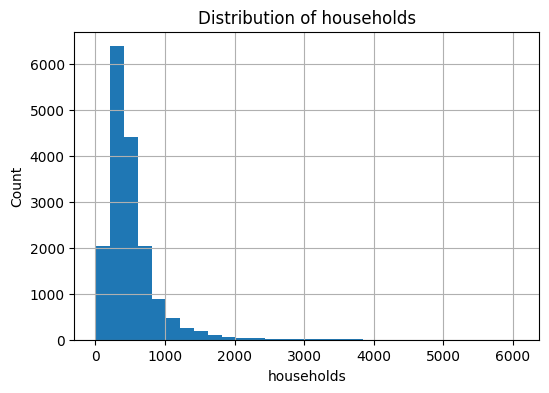

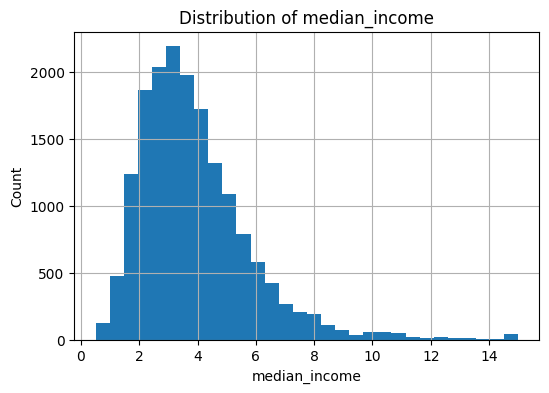

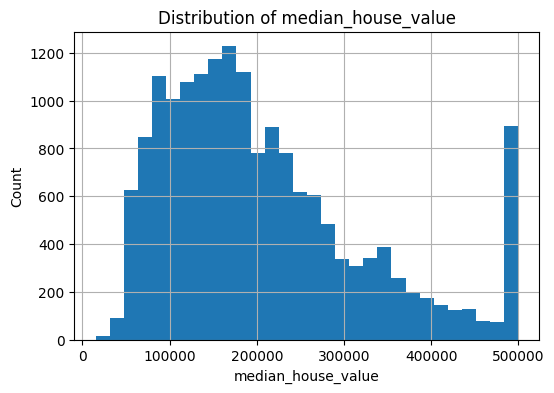

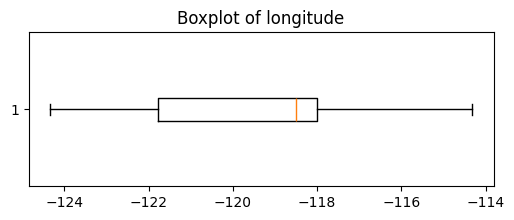

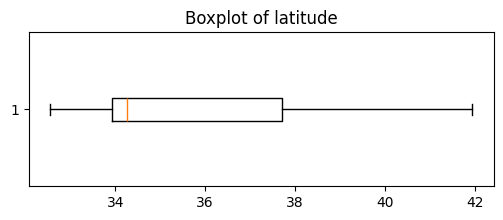

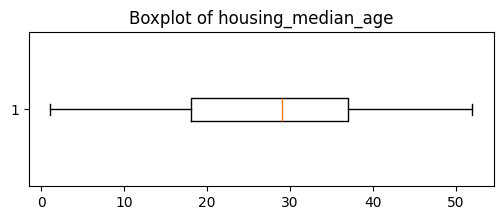

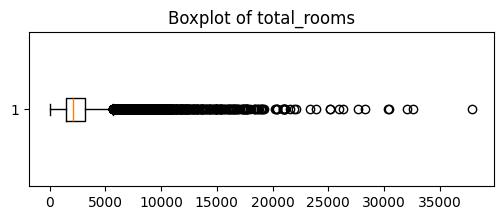

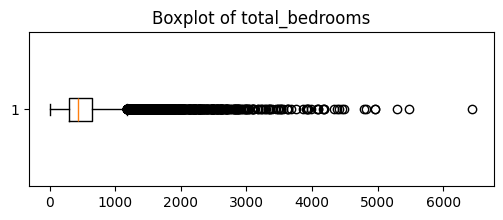

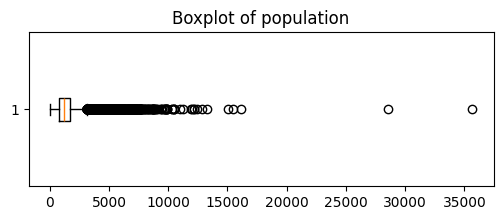

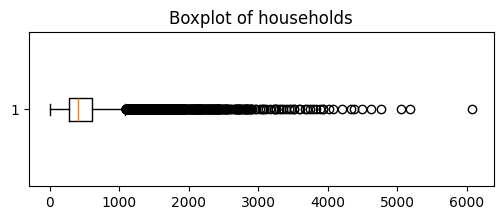

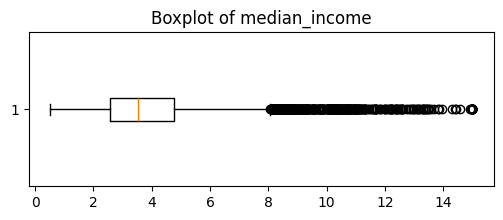

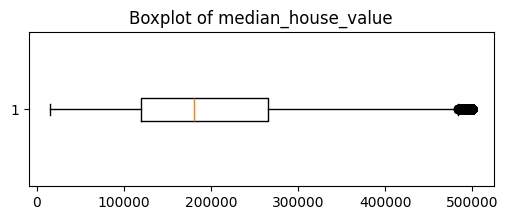


Skewness of numerical features:
population            5.187212
total_rooms           4.002730
households            3.342668
total_bedrooms        3.322637
median_income         1.626693
median_house_value    0.973037
latitude              0.471801
housing_median_age    0.064894
longitude            -0.304003
dtype: float64


In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt
import pandas as pd

# Load a sample DataFrame 'df' - you might need to adjust this to your actual data source
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Select numerical columns
numeric_cols = df.select_dtypes(include=['number']).columns

print("Numerical Columns:")
print(numeric_cols)

# Summary statistics
display(df[numeric_cols].describe())

# Plot distributions
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# Boxplots to identify heavy tails/outliers
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

# Skewness
print("\nSkewness of numerical features:")
print(df[numeric_cols].skew().sort_values(ascending=False))

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Signal Test 1
Claim: Higher median income is associated with higher house values.

Test: Compare the correlation between median_income and median_house_value.

Verdict: CONFIRMED (if the correlation is positive).

------------------------------------------------

Signal Test 2
Claim: Districts with more total rooms have higher house values.

Test: Compare the correlation between total_rooms and median_house_value.

Verdict: MIXED (the relationship is usually weaker because larger districts naturally contain more rooms).

------------------------------------------------

Signal Test 3
Claim: Older houses have higher house values.

Test: Compare the correlation between housing_median_age and median_house_value.

Verdict: MIXED (or FALSE if the correlation is very weak).

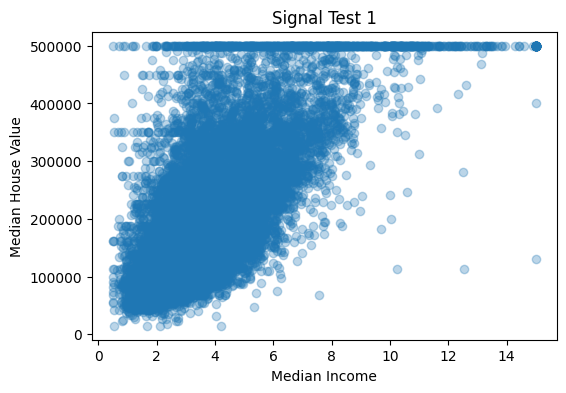

Correlation (Median Income vs House Value): 0.692
Verdict: CONFIRMED


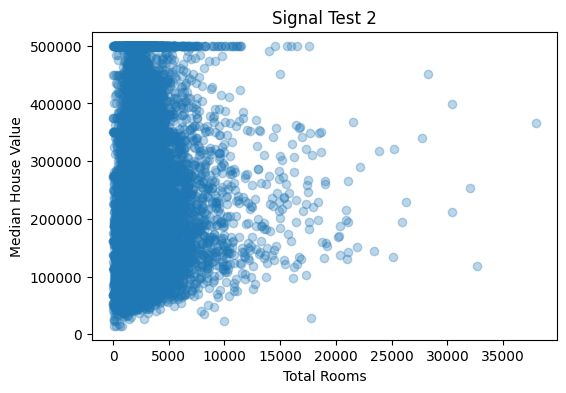


Correlation (Total Rooms vs House Value): 0.131
Verdict: FALSE


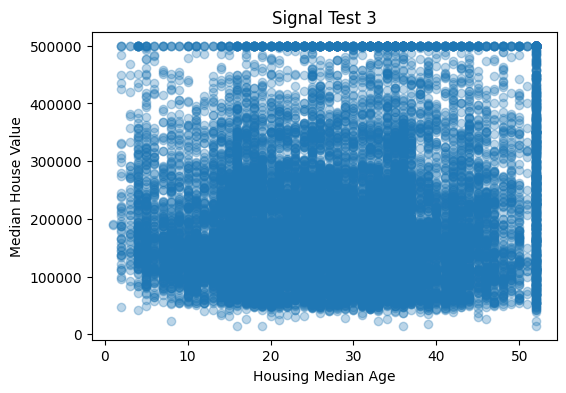


Correlation (Housing Age vs House Value): 0.107
Verdict: FALSE


In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt

# ---------- Signal Test 1 ----------
corr1 = df["median_income"].corr(df["median_house_value"])

plt.figure(figsize=(6,4))
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Signal Test 1")
plt.show()

print(f"Correlation (Median Income vs House Value): {corr1:.3f}")

if corr1 > 0.5:
    print("Verdict: CONFIRMED")
elif corr1 > 0.2:
    print("Verdict: MIXED")
else:
    print("Verdict: FALSE")


# ---------- Signal Test 2 ----------
corr2 = df["total_rooms"].corr(df["median_house_value"])

plt.figure(figsize=(6,4))
plt.scatter(df["total_rooms"], df["median_house_value"], alpha=0.3)
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.title("Signal Test 2")
plt.show()

print(f"\nCorrelation (Total Rooms vs House Value): {corr2:.3f}")

if corr2 > 0.5:
    print("Verdict: CONFIRMED")
elif corr2 > 0.2:
    print("Verdict: MIXED")
else:
    print("Verdict: FALSE")


# ---------- Signal Test 3 ----------
corr3 = df["housing_median_age"].corr(df["median_house_value"])

plt.figure(figsize=(6,4))
plt.scatter(df["housing_median_age"], df["median_house_value"], alpha=0.3)
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.title("Signal Test 3")
plt.show()

print(f"\nCorrelation (Housing Age vs House Value): {corr3:.3f}")

if corr3 > 0.5:
    print("Verdict: CONFIRMED")
elif corr3 > 0.2:
    print("Verdict: MIXED")
else:
    print("Verdict: FALSE")

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Flag-linked Test

Assumed Rule:
Districts with higher median income tend to have higher median house values.

Test:
Compare the relationship between median_income and median_house_value using a correlation analysis and scatter plot.

Verdict:
The result supports the assumption if a positive correlation is observed. Otherwise, the assumption is only partially supported or not supported.

Correlation: 0.692


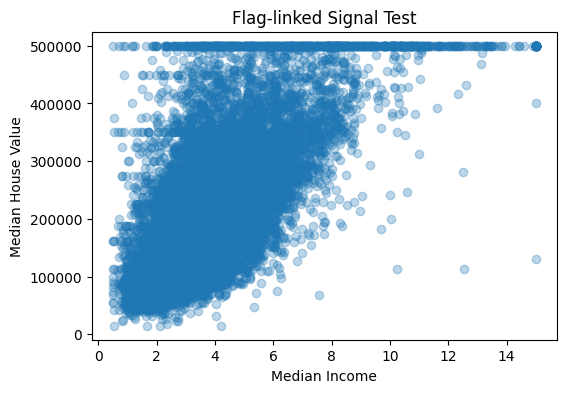

Verdict: CONFIRMED


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt

# Correlation between income and house value
corr = df["median_income"].corr(df["median_house_value"])

print(f"Correlation: {corr:.3f}")

plt.figure(figsize=(6,4))
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Flag-linked Signal Test")
plt.show()

# Verdict
if corr >= 0.5:
    verdict = "CONFIRMED"
elif corr >= 0.2:
    verdict = "MIXED"
else:
    verdict = "FALSE"

print(f"Verdict: {verdict}")

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The signal tests suggest that median income is the strongest predictor of house values, while other features such as total rooms and housing age show weaker or mixed relationships. This means analysts should focus on the features with consistently strong signals and avoid making decisions based on weak or inconsistent patterns. Signal auditing helps identify which relationships are reliable before building predictive models.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
pass

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.